<b>Detecting AI-Generated Text</b>

<i>In this project, I am to build a model which can recognise which text was written by human or AI.</i>

1.<u>Data preprocessing<u>

<i>Importing modules</i>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<i>Importing dataset</i>

In [2]:
dataset=pd.read_csv(r"C:\Users\Abhijyot Singh Roda\Desktop\Coding Stuff\Python\Projects\Not so random projects\ML Projects\Datasets\AI Generated Essays Dataset.csv")

<i>Information about the dataset</i>

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       1460 non-null   object
 1   generated  1460 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 22.9+ KB


<i>First 5 rows</i>

In [4]:
dataset.head()

,text,generated
0,"Machine learning, a subset of artificial intel...",1
1,"A decision tree, a prominent machine learning ...",1
2,"Education, a cornerstone of societal progress,...",1
3,"Computers, the backbone of modern technology, ...",1
4,"Chess, a timeless game of strategy and intelle...",1


<i>Last 5 rows</i>

In [5]:
dataset.tail()

,text,generated
1455,There has been a fuss about the Elector Colleg...,0
1456,Limiting car usage has many advantages. Such a...,0
1457,There's a new trend that has been developing f...,0
1458,As we all know cars are a big part of our soci...,0
1459,Cars have been around since the 1800's and hav...,0


<i>Cleaning text</i>

In [14]:
import re
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

corpus=[]
for i in range(1460):
    review=re.sub("[^a-zA-Z]"," ",dataset["text"][i])
    review=review.lower()
    review=review.split()
    ps=PorterStemmer()
    review=[ps.stem(word) for word in review if not word in set(stopwords.words("english"))]
    review=" ".join(review)
    corpus.append(review)

[nltk_data] Downloading package stopwords to C:\Users\Abhijyot Singh
[nltk_data]     Roda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<i>Creating Bag of Words</i>

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

cv=CountVectorizer(max_features=400)
X=cv.fit_transform(corpus).toarray()
y=dataset.iloc[:,-1].values

<i>Splitting the dataset into training and test set</i>

In [16]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

2.<u>Building multiple models</u>

<b>a. Logistic Regression</b>

<i>Model building</i>

In [29]:
from sklearn.linear_model import LogisticRegression

classifier1=LogisticRegression(class_weight="balanced")
classifier1.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


<i>Predicting the values for training and test set</i>

In [30]:
y_pred_train_1=classifier1.predict(X_train)
y_pred_test_1=classifier1.predict(X_test)

print("For the training set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train_1.reshape(len(y_pred_train_1),1)),axis=1))
print()

print("For the test set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test_1.reshape(len(y_pred_test_1),1)),axis=1))

For the training set:
[Actual_Observations Predicted_Observations]
[[0 0]
 [0 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]

For the test set:
[Actual_Observations Predicted_Observations]
[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [

<i>Accuracy of the model</i>

Accuracy for the training set: 100.000000%
Accuracy for the test set: 99.657534%

Confusion matrix for the training set:


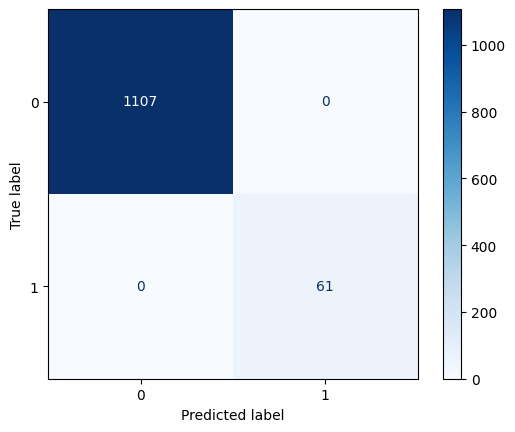

Confusion matrix for the test set:


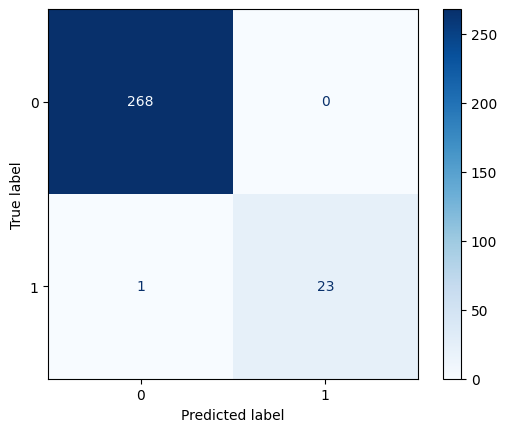

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

con_mat_lr_1=confusion_matrix(y_train,y_pred_train_1)
con_mat_lr_2=confusion_matrix(y_test,y_pred_test_1)

disp_lr_1=ConfusionMatrixDisplay(confusion_matrix=con_mat_lr_1)
disp_lr_2=ConfusionMatrixDisplay(confusion_matrix=con_mat_lr_2)

print(f"Accuracy for the training set: {accuracy_score(y_train,y_pred_train_1)*100:2f}%")
print(f"Accuracy for the test set: {accuracy_score(y_test,y_pred_test_1)*100:2f}%")
print()

print("Confusion matrix for the training set:")
disp_lr_1.plot(cmap=plt.cm.Blues)
plt.show()

print("Confusion matrix for the test set:")
disp_lr_2.plot(cmap=plt.cm.Blues)
plt.show()

<i>Classification Report</i>

In [32]:
from sklearn.metrics import classification_report

print("Classification report for the training set:")
print(classification_report(y_train,y_pred_train_1))
print()

print("Classification report for the test set:")
print(classification_report(y_test,y_pred_test_1))

Classification report for the training set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1107
           1       1.00      1.00      1.00        61

    accuracy                           1.00      1168
   macro avg       1.00      1.00      1.00      1168
weighted avg       1.00      1.00      1.00      1168


Classification report for the test set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       268
           1       1.00      0.96      0.98        24

    accuracy                           1.00       292
   macro avg       1.00      0.98      0.99       292
weighted avg       1.00      1.00      1.00       292



<b>b. K-Nearest Neighbours Classification</b>

<i>Model building</i>

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

classifier2=KNeighborsClassifier(n_neighbors=5,metric="minkowski",p=2)
classifier2.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


<i>Predicting the values for training and test set</i>

In [22]:
y_pred_train_2=classifier2.predict(X_train)
y_pred_test_2=classifier2.predict(X_test)

print("For the training set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train_2.reshape(len(y_pred_train_2),1)),axis=1))
print()

print("For the test set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test_2.reshape(len(y_pred_test_2),1)),axis=1))

For the training set:
[Actual_Observations Predicted_Observations]
[[0 0]
 [0 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]

For the test set:
[Actual_Observations Predicted_Observations]
[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [

<i>Accuracy of the model</i>

Accuracy for the training set: 99.058219%
Accuracy for the test set: 98.630137%

Confusion matrix for the training set:


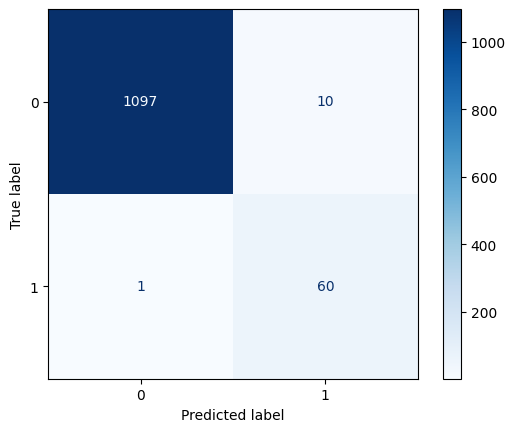

Confusion matrix for the test set:


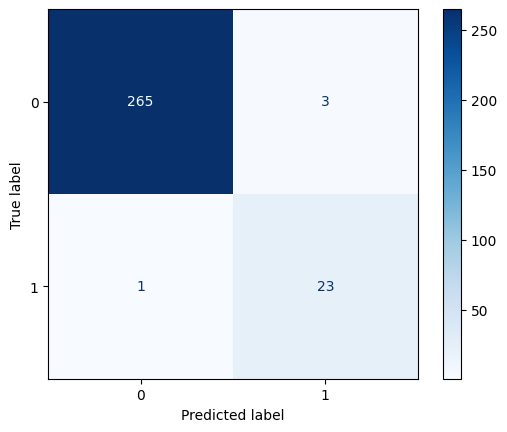

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

con_mat_knn_1=confusion_matrix(y_train,y_pred_train_2)
con_mat_knn_2=confusion_matrix(y_test,y_pred_test_2)

disp_knn_1=ConfusionMatrixDisplay(confusion_matrix=con_mat_knn_1)
disp_knn_2=ConfusionMatrixDisplay(confusion_matrix=con_mat_knn_2)

print(f"Accuracy for the training set: {accuracy_score(y_train,y_pred_train_2)*100:2f}%")
print(f"Accuracy for the test set: {accuracy_score(y_test,y_pred_test_2)*100:2f}%")
print()

print("Confusion matrix for the training set:")
disp_knn_1.plot(cmap=plt.cm.Blues)
plt.show()

print("Confusion matrix for the test set:")
disp_knn_2.plot(cmap=plt.cm.Blues)
plt.show()

<i>Classification Report</i>

In [24]:
from sklearn.metrics import classification_report

print("Classification report for the training set:")
print(classification_report(y_train,y_pred_train_2))
print()

print("Classification report for the test set:")
print(classification_report(y_test,y_pred_test_2))

Classification report for the training set:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1107
           1       0.86      0.98      0.92        61

    accuracy                           0.99      1168
   macro avg       0.93      0.99      0.96      1168
weighted avg       0.99      0.99      0.99      1168


Classification report for the test set:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       268
           1       0.88      0.96      0.92        24

    accuracy                           0.99       292
   macro avg       0.94      0.97      0.96       292
weighted avg       0.99      0.99      0.99       292



<b>c. Naive Baye's Classification</b>

<i>Model building</i>

In [ ]:
from sklearn.naive_bayes import GaussianNB

classifier3=GaussianNB()
classifier3.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


<i>Predicting the values for training and test set</i>

In [26]:
y_pred_train_3=classifier3.predict(X_train)
y_pred_test_3=classifier3.predict(X_test)

print("For the training set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train_3.reshape(len(y_pred_train_3),1)),axis=1))
print()

print("For the test set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test_3.reshape(len(y_pred_test_3),1)),axis=1))

For the training set:
[Actual_Observations Predicted_Observations]
[[0 0]
 [0 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]

For the test set:
[Actual_Observations Predicted_Observations]
[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [

<i>Accuracy of the model</i>

Accuracy for the training set: 100.000000%
Accuracy for the test set: 97.602740%

Confusion matrix for the training set:


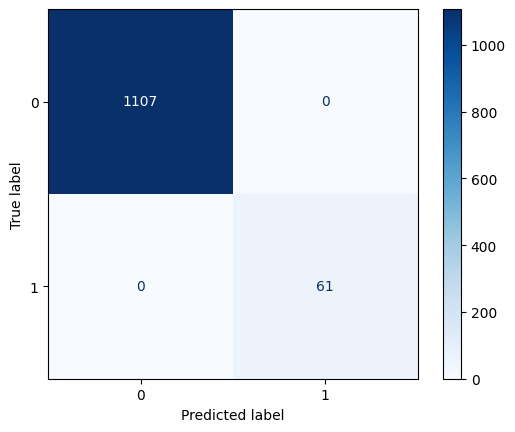

Confusion matrix for the test set:


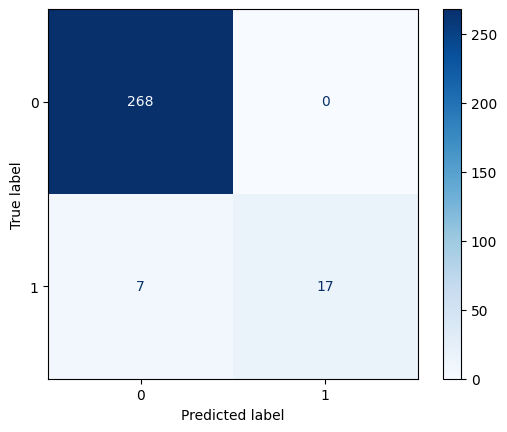

In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

con_mat_nb_1=confusion_matrix(y_train,y_pred_train_3)
con_mat_nb_2=confusion_matrix(y_test,y_pred_test_3)

disp_nb_1=ConfusionMatrixDisplay(confusion_matrix=con_mat_nb_1)
disp_nb_2=ConfusionMatrixDisplay(confusion_matrix=con_mat_nb_2)

print(f"Accuracy for the training set: {accuracy_score(y_train,y_pred_train_3)*100:2f}%")
print(f"Accuracy for the test set: {accuracy_score(y_test,y_pred_test_3)*100:2f}%")
print()

print("Confusion matrix for the training set:")
disp_nb_1.plot(cmap=plt.cm.Blues)
plt.show()

print("Confusion matrix for the test set:")
disp_nb_2.plot(cmap=plt.cm.Blues)
plt.show()

<i>Classification Report</i>

In [28]:
from sklearn.metrics import classification_report

print("Classification report for the training set:")
print(classification_report(y_train,y_pred_train_3))
print()

print("Classification report for the test set:")
print(classification_report(y_test,y_pred_test_3))

Classification report for the training set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1107
           1       1.00      1.00      1.00        61

    accuracy                           1.00      1168
   macro avg       1.00      1.00      1.00      1168
weighted avg       1.00      1.00      1.00      1168


Classification report for the test set:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       268
           1       1.00      0.71      0.83        24

    accuracy                           0.98       292
   macro avg       0.99      0.85      0.91       292
weighted avg       0.98      0.98      0.97       292



<b>d. Decision Tree Classifier</b>

<i>Model building</i>

In [34]:
from sklearn.tree import DecisionTreeClassifier

classifier4=DecisionTreeClassifier(criterion="gini",random_state=0,class_weight="balanced")
classifier4.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


<i>Predicting the values for training and test set</i>

In [35]:
y_pred_train_4=classifier4.predict(X_train)
y_pred_test_4=classifier4.predict(X_test)

print("For the training set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train_4.reshape(len(y_pred_train_4),1)),axis=1))
print()

print("For the test set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test_4.reshape(len(y_pred_test_4),1)),axis=1))

For the training set:
[Actual_Observations Predicted_Observations]
[[0 0]
 [0 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]

For the test set:
[Actual_Observations Predicted_Observations]
[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [

<i>Accuracy of the model</i>

Accuracy for the training set: 100.000000%
Accuracy for the test set: 97.945205%

Confusion matrix for the training set:


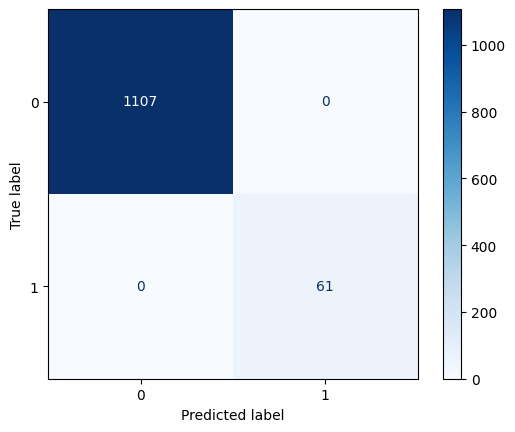

Confusion matrix for the test set:


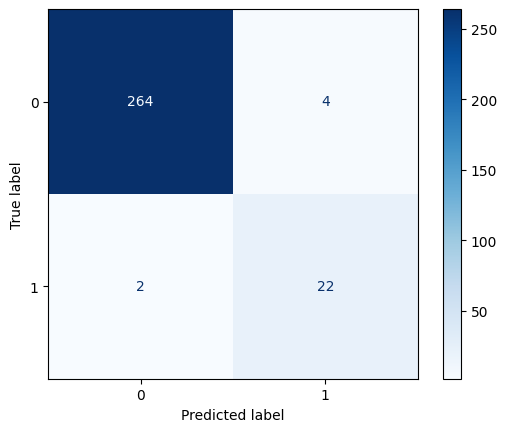

In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

con_mat_dt_1=confusion_matrix(y_train,y_pred_train_4)
con_mat_dt_2=confusion_matrix(y_test,y_pred_test_4)

disp_dt_1=ConfusionMatrixDisplay(confusion_matrix=con_mat_dt_1)
disp_dt_2=ConfusionMatrixDisplay(confusion_matrix=con_mat_dt_2)

print(f"Accuracy for the training set: {accuracy_score(y_train,y_pred_train_4)*100:2f}%")
print(f"Accuracy for the test set: {accuracy_score(y_test,y_pred_test_4)*100:2f}%")
print()

print("Confusion matrix for the training set:")
disp_dt_1.plot(cmap=plt.cm.Blues)
plt.show()

print("Confusion matrix for the test set:")
disp_dt_2.plot(cmap=plt.cm.Blues)
plt.show()

<i>Classification Report</i>

In [41]:
from sklearn.metrics import classification_report

print("Classification report for the training set:")
print(classification_report(y_train,y_pred_train_4))
print()

print("Classification report for the test set:")
print(classification_report(y_test,y_pred_test_4))

Classification report for the training set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1107
           1       1.00      1.00      1.00        61

    accuracy                           1.00      1168
   macro avg       1.00      1.00      1.00      1168
weighted avg       1.00      1.00      1.00      1168


Classification report for the test set:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       268
           1       0.85      0.92      0.88        24

    accuracy                           0.98       292
   macro avg       0.92      0.95      0.93       292
weighted avg       0.98      0.98      0.98       292



<b>e. Random Forest Classifier</b>

<i>Model building</i>

In [37]:
from sklearn.ensemble import RandomForestClassifier

classifier5=RandomForestClassifier(n_estimators=500,random_state=0,criterion="gini",max_depth=5,class_weight="balanced")
classifier5.fit(X_train,y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<i>Predicting the values for training and test set</i>

In [38]:
y_pred_train_5=classifier5.predict(X_train)
y_pred_test_5=classifier5.predict(X_test)

print("For the training set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train_5.reshape(len(y_pred_train_5),1)),axis=1))
print()

print("For the test set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test_5.reshape(len(y_pred_test_5),1)),axis=1))

For the training set:
[Actual_Observations Predicted_Observations]
[[0 0]
 [0 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]

For the test set:
[Actual_Observations Predicted_Observations]
[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [

<i>Accuracy of the model</i>

Accuracy for the training set: 100.000000%
Accuracy for the test set: 99.657534%

Confusion matrix for the training set:


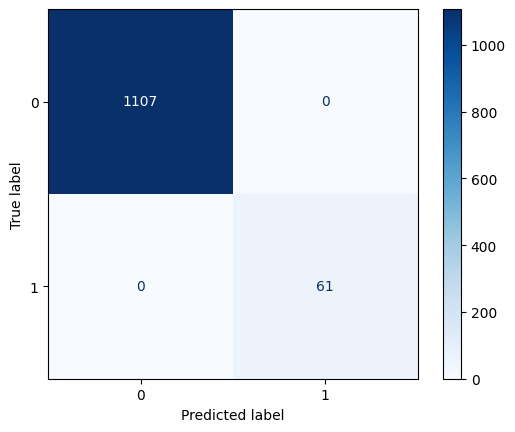

Confusion matrix for the test set:


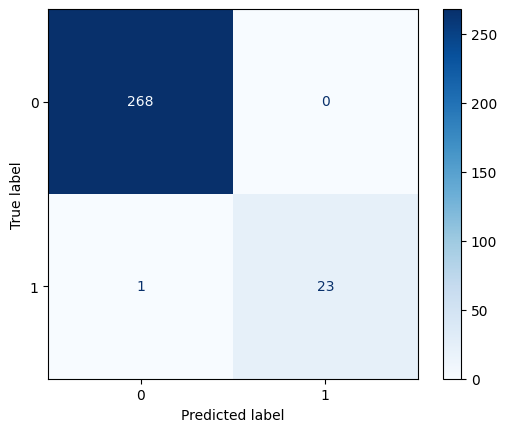

In [39]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

con_mat_rf_1=confusion_matrix(y_train,y_pred_train_5)
con_mat_rf_2=confusion_matrix(y_test,y_pred_test_5)

disp_rf_1=ConfusionMatrixDisplay(confusion_matrix=con_mat_rf_1)
disp_rf_2=ConfusionMatrixDisplay(confusion_matrix=con_mat_rf_2)

print(f"Accuracy for the training set: {accuracy_score(y_train,y_pred_train_5)*100:2f}%")
print(f"Accuracy for the test set: {accuracy_score(y_test,y_pred_test_5)*100:2f}%")
print()

print("Confusion matrix for the training set:")
disp_rf_1.plot(cmap=plt.cm.Blues)
plt.show()

print("Confusion matrix for the test set:")
disp_rf_2.plot(cmap=plt.cm.Blues)
plt.show()

<i>Classification Report</i>

In [40]:
from sklearn.metrics import classification_report

print("Classification report for the training set:")
print(classification_report(y_train,y_pred_train_5))
print()

print("Classification report for the test set:")
print(classification_report(y_test,y_pred_test_5))

Classification report for the training set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1107
           1       1.00      1.00      1.00        61

    accuracy                           1.00      1168
   macro avg       1.00      1.00      1.00      1168
weighted avg       1.00      1.00      1.00      1168


Classification report for the test set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       268
           1       1.00      0.96      0.98        24

    accuracy                           1.00       292
   macro avg       1.00      0.98      0.99       292
weighted avg       1.00      1.00      1.00       292



3.<u>Results</u>

| Model | Train Acc | Test Acc | AI-class Precision | AI-class Recall | AI-class F1 |
|---|---|---|---|---|---|
| Logistic Regression | 100.00% | 99.66% | 1.00 | 0.96 | 0.98 |
| KNN | 99.06% | 98.63% | 0.88 | 0.96 | 0.92 |
| Naive Bayes | 100.00% | 97.60% | 1.00 | 0.71 | 0.83 |
| Decision Tree | 100.00% | 97.95% | 0.85 | 0.92 | 0.88 |
| Random Forest | 100.00% | 99.66% | 1.00 | 0.96 | 0.98 |

**Takeaway:** Given the class imbalance (61 AI vs 1107 human in training; 24 AI vs 268 human in test),
overall accuracy is not the deciding metric — AI-class precision/recall/F1 is. Logistic Regression and
Random Forest tie for best AI-class F1 (0.98). Naive Bayes' AI-class recall (0.71) is a notable weak point
despite a high accuracy score. **Logistic Regression** is selected as the preferred model for its
simplicity, interpretability, and equal performance to Random Forest.

4.<u>Model deployment</u>

In [42]:
import pickle as pk

with open(r"LogisticRegression.pk","wb") as file:
    pk.dump(classifier1,file)
    
with open(r"CountVectorizer.pk","wb") as file:
    pk.dump(cv,file)